In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib as mpl
import scipy.optimize as sco 
import seaborn as sns


In [29]:
## Pulling ticker data for later use ## 
portfolio_groups = {
    "Dom_Eq": ['SPY', 'QQQ', 'IWM'],
    "Intl_Eq": ['EFA', 'EEM'],
    "Fixed_Inc": ['AGG', 'TLT', 'LQD'],
    "Alt": ['GLD', 'VNQ'],
    "Factor": ['MTUM', 'VLUE', 'QUAL', 'USMV']
}
all_tickers = [ticker for group in portfolio_groups.values() for ticker in group]
portfolio_data : pd.DataFrame = yf.download(all_tickers, # type: ignore
                                            period = "5y",
                                            auto_adjust= False,
                                            group_by="column")
if portfolio_data is None:
    raise ValueError("Download failed")
adj_close = portfolio_data["Adj Close"] 
daily_returns = adj_close.pct_change().dropna()


[*********************100%***********************]  14 of 14 completed


In [3]:
## Pulling Metadata for later use ##
ticker_metadata = {
    ticker:group
    for group, tickers in portfolio_groups.items()
    for ticker in tickers
}
ticker_meta_df = (
    pd.DataFrame.from_dict(ticker_metadata, orient = "index", columns = ['group'])
    .reset_index()
    .rename(columns = {"index":"ticker"})
)

In [5]:
beta_series = pd.Series(index = daily_returns.columns, dtype = float)

benchmark_var = daily_returns['SPY'].var()

for col in daily_returns.columns:
    cov = daily_returns[col].cov(daily_returns['SPY'])
    beta = cov / benchmark_var
    beta_series[col] = beta

beta_series

Ticker
AGG     0.073964
EEM     0.771232
EFA     0.773804
GLD     0.152416
IWM     1.115870
LQD     0.186305
MTUM    1.075154
QQQ     1.260616
QUAL    0.989549
SPY     1.000000
TLT     0.068429
USMV    0.595771
VLUE    0.908953
VNQ     0.732165
dtype: float64

In [32]:
## Feature Engineering ## 
expected_returns = daily_returns.mean()
ann_returns = daily_returns.mean()*252
average_trade_volume = portfolio_data['Volume'].mean()
annual_volatility = daily_returns.std() * np.sqrt(252)
corr_matrix = daily_returns.corr()
cov_matrix = daily_returns.cov() * 252
rolling_vol = daily_returns.rolling(30).std() * np.sqrt(252)
cumulative_returns = (1 + daily_returns).cumprod()
running_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns - running_max) / running_max
portfolio_metrics = {
    "returns": ann_returns,
    "volatility": annual_volatility,
    "correlation": corr_matrix,
    "covariance": cov_matrix
}

In [33]:
metrics_table = pd.DataFrame()
metrics_table['expected_returns'] = expected_returns.round(6)
metrics_table['ann_returns'] = ann_returns
metrics_table['annual_volatility'] = annual_volatility
metrics_table['beta'] = beta_series
metrics_table['av_trade_volume'] = average_trade_volume
metrics_table

,expected_returns,ann_returns,annual_volatility,beta,av_trade_volume
Ticker,,,,,
AGG,0.000006,1.428691e-03,0.061050,0.073964,8.180844e+06
EEM,0.000309,7.781325e-02,0.196252,0.771232,3.398172e+07
EFA,0.000396,9.970201e-02,0.165897,0.773804,1.891445e+07
GLD,0.000717,1.807485e-01,0.183294,0.152416,8.909044e+06
IWM,0.000354,8.924546e-02,0.225992,1.115870,3.237881e+07
LQD,-0.000000,-8.656077e-07,0.086488,0.186305,2.409987e+07
MTUM,0.000609,1.535891e-01,0.215114,1.075154,8.931380e+05
QQQ,0.000672,1.693802e-01,0.227550,1.260616,5.103246e+07
QUAL,0.000489,1.231342e-01,0.173962,0.989549,1.471541e+06


<Axes: xlabel='Ticker', ylabel='Ticker'>

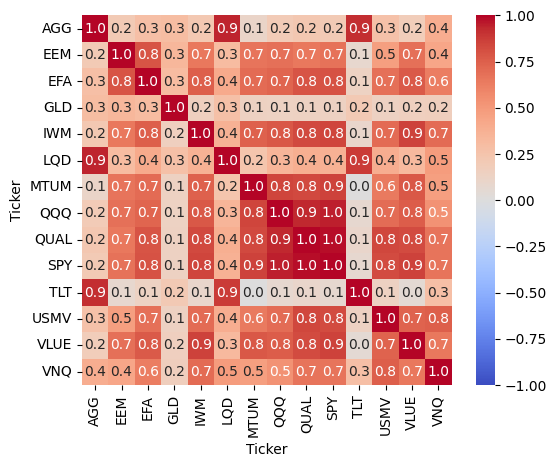

In [ ]:
# For Later
# sns.heatmap(corr_matrix, annot = True, fmt = ".1f", cmap = "coolwarm", vmin=-1, vmax=1, square = True)